# VASA v1 Training

---
Masking strategy (single sensor fixed random masking per epoch)

In [1]:
import os
# Suppress TensorFlow C++ backend logs:
# 0 = all logs, 1 = filter INFO, 2 = filter INFO/WARNING, 3 = filter INFO/WARNING/ERROR
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
# Optional: reduce AutoGraph verbosity
os.environ["AUTOGRAPH_VERBOSITY"] = "0"
#-----------------------------------------------------------------------------------------------------------------#
import sys, time, shutil, platform, multiprocessing, psutil, warnings, VASA, logging, zipfile
#-----------------------------------------------------------------------------------------------------------------#
# Command to make all plots interactive
%matplotlib ipympl
#-----------------------------------------------------------------------------------------------------------------#
# Import packages as
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#-----------------------------------------------------------------------------------------------------------------#
# From package import function
from obspy import read
from pathlib import Path
from obspy.geodetics import gps2dist_azimuth
from scipy.signal import butter, sosfiltfilt, correlate
#-----------------------------------------------------------------------------------------------------------------#
# ML Packages 
import tensorflow as tf
from keras.utils import *
from tensorflow.keras import *
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger, ReduceLROnPlateau
tf.get_logger().setLevel(logging.ERROR)
#-----------------------------------------------------------------------------------------------------------------#
print(f"Python Platform: {platform.platform()}")
print(f"Tensorflow Version: {tf.__version__}")
print(f"Keras Version: {tf.keras.__version__}")
print()
print(f"Python {sys.version}")
print()
print(f"Number of cores available for processing: {multiprocessing.cpu_count()}")
print(f"Total memory available: {psutil.virtual_memory().total / 1e9, 'GB'}")
print()
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU'))) # check if TensorFlow is using GPU
#-----------------------------------------------------------------------------------------------------------------#
# Ignore non-critical warnings
warnings.filterwarnings('ignore')
#-----------------------------------------------------------------------------------------------------------------#
# Download dataset from SSD
db_dir = Path("Database/Preprocessed")
X_train = np.load(db_dir / "X_train5.npy")
X_test = np.load(db_dir / "X_test5.npy")
meta_train = pd.read_pickle(db_dir / "meta_train.pkl").reset_index(drop=True)
meta_test = pd.read_pickle(db_dir / "meta_test.pkl").reset_index(drop=True)
print("Number of events in train set: "+str(X_train.shape[0]))
print("Number of events in test set: "+str(X_test.shape[0]))
print("Each event has input of shape: [" + str(X_train.shape[1]) + ", "+str(X_train.shape[2]) + ", "+ str(X_train.shape[3]) + "]")

2026-05-15 14:43:31.021366: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778874211.038768  629112 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778874211.044107  629112 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Python Platform: Linux-5.15.0-1083-nvidia-x86_64-with-glibc2.35
Tensorflow Version: 2.18.0
Keras Version: 3.8.0

Python 3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]

Number of cores available for processing: 128
Total memory available: (2164.307132416, 'GB')

Num GPUs Available: 2
Number of events in train set: 24000
Number of events in test set: 6000
Each event has input of shape: [3, 10, 2400]


---
Modify dimensions to match [B, S, T, C]

In [2]:
# Convert from [N, C, S, T] to [N, S, T, C]
X_train = np.transpose(X_train, (0, 2, 3, 1)).astype(np.float32)
X_test = np.transpose(X_test, (0, 2, 3, 1)).astype(np.float32)

print("X_train model shape:", X_train.shape)
print("X_test model shape:", X_test.shape)
print("X_train min/max:", X_train.min(), X_train.max())
print("X_train mean abs:", np.mean(np.abs(X_train)))
print("X_train std:", np.std(X_train))

X_train model shape: (24000, 10, 2400, 3)
X_test model shape: (6000, 10, 2400, 3)
X_train min/max: -0.0021296914 0.002113805
X_train mean abs: 4.489187e-08
X_train std: 1.290824e-06


---
Construct distance matrix

Station order:
['BPH01', 'BPH02', 'BPH03', 'BPH06', 'BPH07', 'BPH08', 'BPH09', 'BPH10', 'BPH11', 'BPH13']
D_km shape: (10, 10)
CPU times: user 510 ms, sys: 33.7 ms, total: 543 ms
Wall time: 543 ms


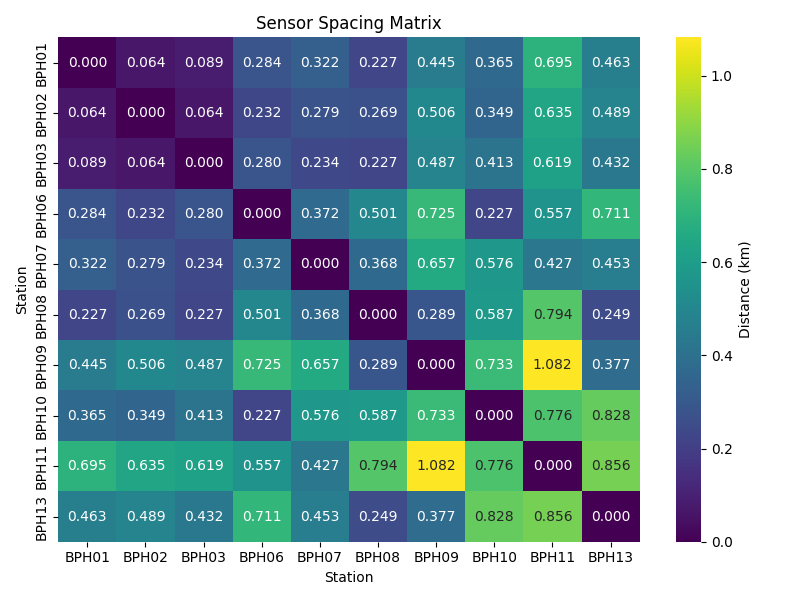

In [3]:
%%time
# Stations used in X[:, :, :, :] after removing BPH04, BPH05, BPH12
station_order = ["BPH01", "BPH02", "BPH03",
                 "BPH06", "BPH07", "BPH08",
                 "BPH09", "BPH10", "BPH11", "BPH13"]

site_path = Path("PFO.site")

D_norm, D_km, station_coords_used = VASA.build_distance_matrix_from_site(
    site_path=site_path,
    station_order=station_order,
    use_elevation=False,
    normalize=True
)

print("Station order:")
print(station_coords_used["station"].tolist())

print("D_km shape:", D_km.shape)

fig = plt.figure(figsize=(8, 6))
sns.heatmap(
    D_km,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    xticklabels=station_order,
    yticklabels=station_order,
    cbar_kws={"label": "Distance (km)"}
)
plt.title("Sensor Spacing Matrix")
plt.xlabel("Station")
plt.ylabel("Station")
plt.tight_layout()

---
Context scaling and build datasets (just for sanity check)

In [4]:
%%time
# Build tf.dataset
batch_size = 128

global_center, global_scale = VASA.compute_global_component_mad_scale(
    X_train,
    n_events=X_train.shape[0],
    seed=123
)

train_fixed_ds, epoch_indices = VASA.make_vasa_epoch_train_dataset_global_scaled_3branch_stateless_oversampled(
    X_train,
    meta_train,
    D_norm,
    batch_size=batch_size,
    global_center=global_center,
    global_scale=global_scale,
    epoch_seed=1000,
    shuffle_buffer=2048,
    noise_pct=2.5,
    max_shift_seconds=5.0,
    use_signal_gain=False,
    sampling_rate=40.0,
    output_gain=1.0,
    final_clip=100.0,
    scale_type="asinh",
    mag_threshold=2.0,
    target_large_frac=0.25
)

print(train_fixed_ds)

I0000 00:00:1778874263.048375  629112 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79194 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:07:00.0, compute capability: 8.0
I0000 00:00:1778874263.050752  629112 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 79194 MB memory:  -> device: 1, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:0f:00.0, compute capability: 8.0


<_PrefetchDataset element_spec=({'seismic_input': TensorSpec(shape=(None, 10, 2400, 6), dtype=tf.float32, name=None), 'distance_input': TensorSpec(shape=(None, 10, 10), dtype=tf.float32, name=None)}, {'Z_Output': TensorSpec(shape=(None, 10, 2400, 2), dtype=tf.float32, name=None), 'N_Output': TensorSpec(shape=(None, 10, 2400, 2), dtype=tf.float32, name=None), 'E_Output': TensorSpec(shape=(None, 10, 2400, 2), dtype=tf.float32, name=None)})>
CPU times: user 42.7 s, sys: 9.28 s, total: 51.9 s
Wall time: 52.4 s


In [5]:
%%time
# Build validation dataset

val_ds = VASA.make_vasa_val_dataset_global_scaled_3branch(
    X_test,
    meta_test,
    D_norm,
    batch_size=batch_size,
    global_center=global_center,
    global_scale=global_scale,
    seed=2024,
    output_gain=1.0,
    final_clip=100.0,
    scale_type="asinh",
    sampling_rate=40.0
)

print(val_ds)

<_PrefetchDataset element_spec=({'seismic_input': TensorSpec(shape=(None, 10, 2400, 6), dtype=tf.float32, name=None), 'distance_input': TensorSpec(shape=(None, 10, 10), dtype=tf.float32, name=None)}, {'Z_Output': TensorSpec(shape=(None, 10, 2400, 2), dtype=tf.float32, name=None), 'N_Output': TensorSpec(shape=(None, 10, 2400, 2), dtype=tf.float32, name=None), 'E_Output': TensorSpec(shape=(None, 10, 2400, 2), dtype=tf.float32, name=None)})>
CPU times: user 1.39 s, sys: 953 ms, total: 2.35 s
Wall time: 2.35 s


---
Sanity check

In [6]:
%%time
batch = next(iter(train_fixed_ds))
VASA.sanity_check_batch(batch, mode="3branch")

x_model: (128, 10, 2400, 6)
x_masked: (128, 10, 2400, 3)
observed_input: (128, 10, 2400, 3)

Z_Output
y_true: (128, 10, 2400, 1)
mask: (128, 10, 2400, 1)
masked fraction: 0.1
observed unique: [1. 0.]
mask unique: [0. 1.]
max abs input where mask=1: 0.0
max abs target where mask=1: 8.60858
mean abs target where mask=1: 0.9162736
zero baseline RMSE: 1.3164082765579224
max abs observed + mask - 1: 0.0

N_Output
y_true: (128, 10, 2400, 1)
mask: (128, 10, 2400, 1)
masked fraction: 0.1
observed unique: [1. 0.]
mask unique: [0. 1.]
max abs input where mask=1: 0.0
max abs target where mask=1: 8.753608
mean abs target where mask=1: 0.9378066
zero baseline RMSE: 1.3677010536193848
max abs observed + mask - 1: 0.0

E_Output
y_true: (128, 10, 2400, 1)
mask: (128, 10, 2400, 1)
masked fraction: 0.1
observed unique: [1. 0.]
mask unique: [0. 1.]
max abs input where mask=1: 0.0
max abs target where mask=1: 8.786104
mean abs target where mask=1: 0.93955976
zero baseline RMSE: 1.3679436445236206
max abs 

In [7]:
%%time
batch = next(iter(train_fixed_ds))
clip_stats = VASA.print_clip_fraction_from_batch(batch, mode="3branch", clip_value=100.0)


Z_Output
y_true: (128, 10, 2400, 1)
mask: (128, 10, 2400, 1)
overall clip fraction: 0.0
masked clip fraction: 0.0

N_Output
y_true: (128, 10, 2400, 1)
mask: (128, 10, 2400, 1)
overall clip fraction: 0.0
masked clip fraction: 0.0

E_Output
y_true: (128, 10, 2400, 1)
mask: (128, 10, 2400, 1)
overall clip fraction: 0.0
masked clip fraction: 0.0
CPU times: user 12.6 s, sys: 1.02 s, total: 13.6 s
Wall time: 597 ms


---
Build model

In [8]:
%%time
# Build model
sensor_dim   = 10
temporal_dim = 2400
channel_dim  = 6
lr           = 1e-3
num_heads    = 5
num_blocks   = 3

vasa = VASA.build_VASA(sensor_dim,
                       temporal_dim,
                       channel_dim,
                       lr,
                       num_heads=num_heads,
                       num_transformer_blocks=num_blocks)
vasa.summary()

Model: "VASA"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seismic_input       │ (None, 10, 2400,  │          0 │ -                 │
│ (InputLayer)        │ 6)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Slice_Z_Wave        │ (None, 10, 2400,  │          0 │ seismic_input[0]… │
│ (Lambda)            │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Slice_Z_Mask        │ (None, 10, 2400,  │          0 │ seismic_input[0]… │
│ (Lambda)            │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Slice_N_Wave        │ (None, 10, 2400,  │          0 │ seismic_input[0]… │
│ (Lambda)            │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Slice_N_Mask        │ (None, 10, 2400,  │          0 │ seismic_input[0]… │
│ (Lambda)            │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Slice_E_Wave        │ (None, 10, 2400,  │          0 │ seismic_input[0]… │
│ (Lambda)            │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Slice_E_Mask        │ (None, 10, 2400,  │          0 │ seismic_input[0]… │
│ (Lambda)            │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Z_Branch_Input      │ (None, 10, 2400,  │          0 │ Slice_Z_Wave[0][… │
│ (Concatenate)       │ 2)                │            │ Slice_Z_Mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ N_Branch_Input      │ (None, 10, 2400,  │          0 │ Slice_N_Wave[0][… │
│ (Concatenate)       │ 2)                │            │ Slice_N_Mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ E_Branch_Input      │ (None, 10, 2400,  │          0 │ Slice_E_Wave[0][… │
│ (Concatenate)       │ 2)                │            │ Slice_E_Mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Z_Waveform_Input    │ (None, 10, 2400,  │          0 │ Z_Branch_Input[0… │
│ (Lambda)            │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ N_Waveform_Input    │ (None, 10, 2400,  │          0 │ N_Branch_Input[0… │
│ (Lambda)            │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ E_Waveform_Input    │ (None, 10, 2400,  │          0 │ E_Branch_Input[0… │
│ (Lambda)            │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Z_Conv_1 (Conv2D)   │ (None, 10, 2400,  │        128 │ Z_Waveform_Input… │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ N_Conv_1 (Conv2D)   │ (None, 10, 2400,  │        128 │ N_Waveform_Input… │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ E_Conv_1 (Conv2D)   │ (None, 10, 2400,  │        128 │ E_Waveform_Input… │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Z_LN_2400           │ (None, 10, 2400,  │          8 │ Z_Conv_1[0][0]  

 Total params: 1,284,291 (4.90 MB)

 Trainable params: 1,284,291 (4.90 MB)

 Non-trainable params: 0 (0.00 B)

CPU times: user 2.65 s, sys: 105 ms, total: 2.76 s
Wall time: 2.59 s


---
Define callbacks

In [9]:
%%time
# Callbacks
sum_val_corr_callback = VASA.SumValCorrCallback()

checkpoint_callback = ModelCheckpoint(
    filepath="vasa_v1.keras",
    monitor="val_total_corr",
    mode="max",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

csv_logger = CSVLogger(
    filename="training_log.csv",
    separator=",",
    append=True
)

callbacks = [
    sum_val_corr_callback,
    checkpoint_callback,
    csv_logger,
]

# Manual LR schedule
initial_lr = 1e-3
min_lr = 1e-4
patience = 5
max_lr_drops = 10
min_delta = 1e-4

lr_factor = (min_lr / initial_lr) ** (1.0 / max_lr_drops)

best_val_loss = np.inf
bad_epochs = 0
lr_drops = 0

vasa.optimizer.learning_rate.assign(initial_lr)

CPU times: user 1.76 ms, sys: 393 μs, total: 2.15 ms
Wall time: 1.49 ms


<tf.Tensor: shape=(), dtype=float32, numpy=0.0010000000474974513>

---
Train model

In [1]:
# Train with new mask pattern for each epoch
batch_size = 128

base_seed = 1000
num_epochs = 500
noise_pct = 2.5
max_shift_seconds = 5.0

validation_steps = int(np.ceil(X_test.shape[0] / batch_size))

val_ds = VASA.make_vasa_val_dataset_global_scaled_3branch(
    X_test,
    meta_test,
    D_norm,
    batch_size=batch_size,
    global_center=global_center,
    global_scale=global_scale,
    seed=2024,
    sampling_rate=40.0,
    output_gain=1.0,
    final_clip=100.0,
    scale_type="asinh"
)

for epoch in range(num_epochs):
    epoch_seed = base_seed + epoch

    train_epoch_ds, epoch_indices = VASA.make_vasa_epoch_train_dataset_global_scaled_3branch_stateless_oversampled(
        X_train,
        meta_train,
        D_norm,
        batch_size=batch_size,
        global_center=global_center,
        global_scale=global_scale,
        epoch_seed=epoch_seed,
        shuffle_buffer=2048,
        noise_pct=noise_pct,
        max_shift_seconds=max_shift_seconds,
        use_signal_gain=False,
        sampling_rate=40.0,
        output_gain=1.0,
        final_clip=100.0,
        scale_type="asinh",
        mag_threshold=2.0,
        target_large_frac=0.25
    )
    
    current_lr = float(tf.keras.backend.get_value(vasa.optimizer.learning_rate))
    print(f"Epoch {epoch + 1}/{num_epochs} | mask seed = {epoch_seed} | lr = {current_lr:.6g}")

    history = vasa.fit(
        train_epoch_ds,
        validation_data=val_ds,
        epochs=epoch + 1,
        initial_epoch=epoch,
        validation_steps=validation_steps,
        callbacks=callbacks,
        verbose=1
    )

    val_total_loss = history.history["val_loss"][-1]
    
    if val_total_loss < best_val_loss - min_delta:
        best_val_loss = val_total_loss
        bad_epochs = 0
    else:
        bad_epochs += 1
        
    if bad_epochs >= patience and lr_drops < max_lr_drops:
        old_lr = float(tf.keras.backend.get_value(vasa.optimizer.learning_rate))
        new_lr = max(old_lr * lr_factor, min_lr)
        
        vasa.optimizer.learning_rate.assign(new_lr)
        
        lr_drops += 1
        bad_epochs = 0
        
        print(
            f"\nReducing LR: {old_lr:.6g} -> {new_lr:.6g} "
            f"({lr_drops}/{max_lr_drops} drops)"
        )

---
Continuing training to 1000 epochs

In [10]:
%%time
sum_val_corr_callback = VASA.SumValCorrCallback()

checkpoint_callback = ModelCheckpoint(
    filepath="vasa_v1_1000epochs.keras",
    monitor="val_total_corr",
    mode="max",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

csv_logger = CSVLogger(
    filename="training_log.csv",
    separator=",",
    append=True
)

callbacks = [sum_val_corr_callback, checkpoint_callback, csv_logger]

batch_size = 128
base_seed = 1000
noise_pct = 2.5
max_shift_seconds = 5.0
start_epoch = 470
end_epoch = 1000

# Rebuild model instead of load_model()
vasa = VASA.build_VASA(
    sensor_dim=10,
    temporal_dim=2400,
    channel_dim=6,
    lr=1e-4,
    num_heads=5,                  # match training
    num_transformer_blocks=3
)

vasa.load_weights("vasa_v1.keras")
vasa.optimizer.learning_rate.assign(1e-4)

validation_steps = int(np.ceil(X_test.shape[0] / batch_size))

val_ds = VASA.make_vasa_val_dataset_global_scaled_3branch(
    X_test,
    meta_test,
    D_norm,
    batch_size=batch_size,
    global_center=global_center,
    global_scale=global_scale,
    seed=2024,
    output_gain=1.0,
    final_clip=100.0,
    scale_type="asinh",
)

initial_lr = 1e-3
min_lr = 1e-4
patience = 5
max_lr_drops = 10
min_delta = 1e-4
lr_factor = (min_lr / initial_lr) ** (1.0 / max_lr_drops)

def restore_schedule_state_from_log(csv_path, n_completed_epochs, min_delta, patience, max_lr_drops):
    log_df = pd.read_csv(csv_path).iloc[:n_completed_epochs]

    best_val_loss = np.inf
    bad_epochs = 0
    lr_drops = 0

    for val_total_loss in log_df["val_loss"].to_numpy():
        if val_total_loss < best_val_loss - min_delta:
            best_val_loss = val_total_loss
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience and lr_drops < max_lr_drops:
            lr_drops += 1
            bad_epochs = 0

    return best_val_loss, bad_epochs, lr_drops
    
csv_log_path = "training_log.csv"
best_val_loss, bad_epochs, lr_drops = restore_schedule_state_from_log(
    csv_log_path,
    n_completed_epochs=start_epoch,
    min_delta=min_delta,
    patience=patience,
    max_lr_drops=max_lr_drops,
)

print("Restored schedule state:")
print("best_val_loss =", best_val_loss)
print("bad_epochs    =", bad_epochs)
print("lr_drops      =", lr_drops)
print("current lr    =", float(tf.keras.backend.get_value(vasa.optimizer.learning_rate)))

Restored schedule state:
best_val_loss = 2.6407289505004883
bad_epochs    = 1
lr_drops      = 10
current lr    = 9.999999747378752e-05
CPU times: user 2.68 s, sys: 1.24 s, total: 3.91 s
Wall time: 3.93 s


In [2]:
# Continue training
for epoch in range(start_epoch, end_epoch):
    epoch_seed = base_seed + epoch

    train_epoch_ds, epoch_indices = VASA.make_vasa_epoch_train_dataset_global_scaled_3branch_stateless_oversampled(
        X_train,
        meta_train,
        D_norm,
        batch_size=batch_size,
        global_center=global_center,
        global_scale=global_scale,
        epoch_seed=epoch_seed,
        shuffle_buffer=2048,
        noise_pct=noise_pct,
        max_shift_seconds=max_shift_seconds,
        use_signal_gain=False,
        sampling_rate=40.0,
        output_gain=1.0,
        final_clip=100.0,
        scale_type="asinh",
        mag_threshold=2.0,
        target_large_frac=0.25,
    )

    current_lr = float(tf.keras.backend.get_value(vasa.optimizer.learning_rate))
    print(f"Epoch {epoch + 1}/{end_epoch} | mask seed = {epoch_seed} | lr = {current_lr:.6g}")

    history = vasa.fit(
        train_epoch_ds,
        validation_data=val_ds,
        epochs=epoch + 1,
        initial_epoch=epoch,
        validation_steps=validation_steps,
        callbacks=callbacks,
        verbose=1
    )

    val_total_loss = history.history["val_loss"][-1]

    if val_total_loss < best_val_loss - min_delta:
        best_val_loss = val_total_loss
        bad_epochs = 0
    else:
        bad_epochs += 1

    if bad_epochs >= patience and lr_drops < max_lr_drops:
        old_lr = float(tf.keras.backend.get_value(vasa.optimizer.learning_rate))
        new_lr = max(old_lr * lr_factor, min_lr)

        vasa.optimizer.learning_rate.assign(new_lr)

        lr_drops += 1
        bad_epochs = 0

        print(
            f"\nReducing LR: {old_lr:.6g} -> {new_lr:.6g} "
            f"({lr_drops}/{max_lr_drops} drops)"
        )


---
Plot training results

Best epoch: 993
Best val_total_corr: 2.6906


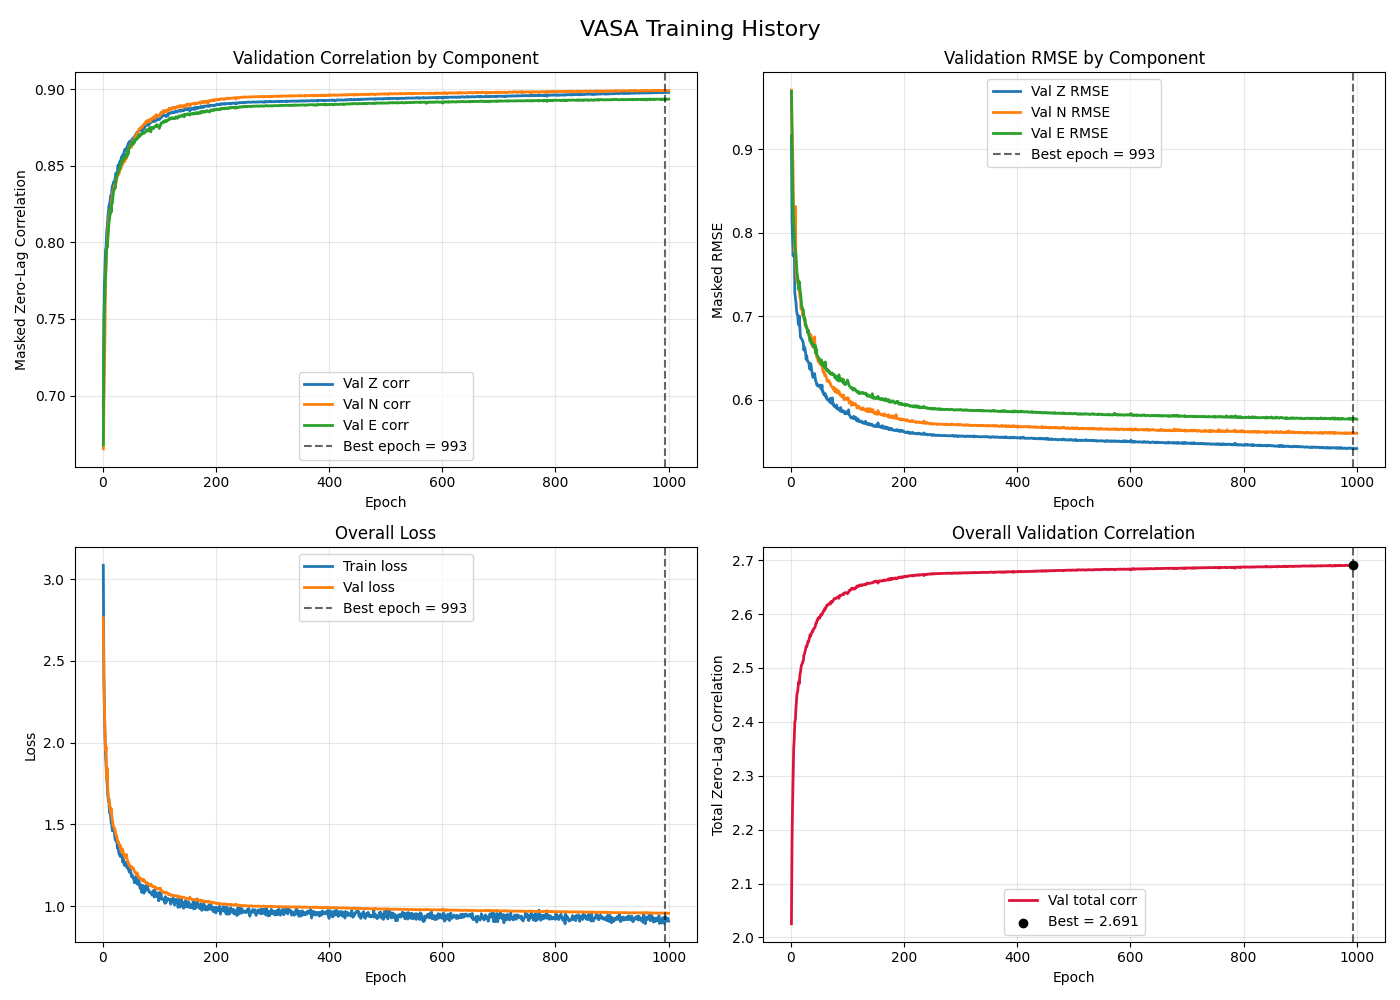

In [8]:
# -----------------------------
# Load training log
# -----------------------------
csv_path = "training_log.csv"
df = pd.read_csv(csv_path)

# If epochs start at 0, make a 1-based version for plotting
epochs = df["epoch"] + 1

# Best epoch based on your monitored validation metric
best_idx = df["val_total_corr"].idxmax()
best_epoch = epochs.iloc[best_idx]
best_val_total_corr = df.loc[best_idx, "val_total_corr"]

print(f"Best epoch: {best_epoch}")
print(f"Best val_total_corr: {best_val_total_corr:.4f}")

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10), clear=True)

# 1) Validation correlation by component
ax = axes[0, 0]
ax.plot(epochs, df["val_Z_Output_masked_1c_corr_metric_2ch"], label="Val Z corr", lw=2)
ax.plot(epochs, df["val_N_Output_masked_1c_corr_metric_2ch"], label="Val N corr", lw=2)
ax.plot(epochs, df["val_E_Output_masked_1c_corr_metric_2ch"], label="Val E corr", lw=2)
ax.axvline(best_epoch, color="k", ls="--", alpha=0.6, label=f"Best epoch = {best_epoch}")
ax.set_title("Validation Correlation by Component")
ax.set_xlabel("Epoch")
ax.set_ylabel("Masked Zero-Lag Correlation")
ax.grid(alpha=0.3)
ax.legend()

# 2) Validation RMSE by component
ax = axes[0, 1]
ax.plot(epochs, df["val_Z_Output_masked_1c_rmse_metric_2ch"], label="Val Z RMSE", lw=2)
ax.plot(epochs, df["val_N_Output_masked_1c_rmse_metric_2ch"], label="Val N RMSE", lw=2)
ax.plot(epochs, df["val_E_Output_masked_1c_rmse_metric_2ch"], label="Val E RMSE", lw=2)
ax.axvline(best_epoch, color="k", ls="--", alpha=0.6, label=f"Best epoch = {best_epoch}")
ax.set_title("Validation RMSE by Component")
ax.set_xlabel("Epoch")
ax.set_ylabel("Masked RMSE")
ax.grid(alpha=0.3)
ax.legend()

# 3) Overall loss
ax = axes[1, 0]
ax.plot(epochs, df["loss"], label="Train loss", lw=2)
ax.plot(epochs, df["val_loss"], label="Val loss", lw=2)
ax.axvline(best_epoch, color="k", ls="--", alpha=0.6, label=f"Best epoch = {best_epoch}")
ax.set_title("Overall Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(alpha=0.3)
ax.legend()

# 4) Overall validation correlation target
ax = axes[1, 1]
ax.plot(epochs, df["val_total_corr"], color="crimson", lw=2, label="Val total corr")
ax.scatter(best_epoch, best_val_total_corr, color="black", zorder=5,
           label=f"Best = {best_val_total_corr:.3f}")
ax.axvline(best_epoch, color="k", ls="--", alpha=0.6)
ax.set_title("Overall Validation Correlation")
ax.set_xlabel("Epoch")
ax.set_ylabel("Total Zero-Lag Correlation")
ax.grid(alpha=0.3)
ax.legend()

fig.suptitle("VASA Training History", fontsize=16)
fig.tight_layout()
plt.show()

---
Load model

In [8]:
%%time
# Extract weights from the .keras archive
keras_path = Path("vasa_v1_1000epochs.keras")
extract_dir = Path("vasa_v1_extracted")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(keras_path, "r") as z:
    z.extract("model.weights.h5", extract_dir)

weights_path = extract_dir / "model.weights.h5"
print(weights_path)

# Rebuild model
sensor_dim   = 10
temporal_dim = 2400
channel_dim  = 6
lr           = 1e-3
num_heads    = 5
num_blocks   = 3

vasa = VASA.build_VASA(sensor_dim,
                       temporal_dim,
                       channel_dim,
                       lr,
                       num_heads=num_heads,
                       num_transformer_blocks=num_blocks)

vasa.load_weights(str(weights_path))
print("Weights loaded")

vasa_v1_extracted/model.weights.h5
Weights loaded
CPU times: user 2.71 s, sys: 112 ms, total: 2.82 s
Wall time: 2.73 s


---
Evaluating norm xcorr across all components

In [9]:
%%time
# Evaluating stats for all sensors across all events, then averaging over sensors
def evaluate_component_reconstruction_metrics_all_sensors(
    model,
    X_test,
    D_norm,
    global_center,
    global_scale,
    station_order,
    meta_test=None,
    batch_size=32,
    output_gain=1.0,
    final_clip=100.0,
    plot_inverse=True,
    sampling_rate=40.0,
    save_csv_path=None
):
    """
    Evaluate reconstruction metrics for every masked sensor across all test events,
    then average over sensors for each event/component.

    Returns:
        avg_results_df: one row per event per component, averaged over all sensors
        raw_results_df: one row per event per sensor per component
    """
    n_events, sensor_dim, temporal_dim, channel_dim = X_test.shape
    time = np.arange(temporal_dim) / sampling_rate

    rows = []
    component_names = ["BHZ", "BHN", "BHE"]

    for sensor_index, station_name in enumerate(station_order):
        print(f"Evaluating masked station: {station_name} ({sensor_index + 1}/{sensor_dim})")

        for start in range(0, n_events, batch_size):
            end = min(start + batch_size, n_events)
            x_clean_batch = X_test[start:end].astype(np.float32)
            bsz = x_clean_batch.shape[0]

            x_scaled_batch = VASA.global_asinh_scale(
                tf.constant(x_clean_batch),
                global_center=tf.constant(global_center, dtype=tf.float32),
                global_scale=tf.constant(global_scale, dtype=tf.float32),
                output_gain=output_gain,
                final_clip=final_clip
            ).numpy()

            mask_batch = np.zeros_like(x_scaled_batch, dtype=np.float32)
            mask_batch[:, sensor_index, :, :] = 1.0

            observed_batch = 1.0 - mask_batch
            x_masked_batch = x_scaled_batch * observed_batch

            x_model_batch = np.concatenate([x_masked_batch, observed_batch], axis=-1)
            d_model_batch = np.repeat(D_norm[None, ...].astype(np.float32), bsz, axis=0)

            preds = model.predict(
                {
                    "seismic_input": x_model_batch,
                    "distance_input": d_model_batch
                },
                verbose=0
            )

            y_pred_scaled_batch = VASA.get_3branch_predictions(preds)

            true_masked_batch = x_scaled_batch[:, sensor_index, :, :]
            pred_masked_batch = y_pred_scaled_batch[:, sensor_index, :, :]

            if plot_inverse:
                true_batch = VASA.inverse_global_asinh_scale(
                    true_masked_batch,
                    global_center,
                    global_scale,
                    output_gain
                )
                pred_batch = VASA.inverse_global_asinh_scale(
                    pred_masked_batch,
                    global_center,
                    global_scale,
                    output_gain
                )
            else:
                true_batch = true_masked_batch
                pred_batch = pred_masked_batch

            for bi in range(bsz):
                event_idx = start + bi

                meta_row = meta_test.iloc[event_idx] if meta_test is not None else None
                evid = meta_row.get("EVID", meta_row.get("ev_id", np.nan)) if meta_row is not None else np.nan
                date_str = meta_row.get("YY/MM/DD", np.nan) if meta_row is not None else np.nan
                mag = meta_row.get("MAG", np.nan) if meta_row is not None else np.nan
                dist_km = meta_row.get("distance_km", np.nan) if meta_row is not None else np.nan

                for ci, comp_name in enumerate(component_names):
                    y_true = true_batch[bi, :, ci]
                    y_pred = pred_batch[bi, :, ci]

                    lags_sec, x_corr = VASA.norm_xcorr(time, y_true, y_pred)
                    best_idx = int(np.argmax(x_corr))
                    max_corr = float(x_corr[best_idx])
                    best_lag_sec = float(lags_sec[best_idx])

                    amp_stats = VASA.raw_amplitude_ratios(y_true, y_pred)

                    rows.append({
                        "event_index": event_idx,
                        "station": station_name,
                        "sensor_index": sensor_index,
                        "component": comp_name,
                        "max_xcorr": max_corr,
                        "best_lag_sec": best_lag_sec,
                        "abs_best_lag_sec": abs(best_lag_sec),
                        "rms_ratio": amp_stats["rms_ratio"],
                        "peak_ratio": amp_stats["peak_ratio"],
                        "EVID": evid,
                        "YY/MM/DD": date_str,
                        "MAG": mag,
                        "distance_km": dist_km,
                    })

    raw_results_df = pd.DataFrame(rows)

    avg_results_df = (
        raw_results_df
        .groupby(["event_index", "component"], as_index=False)
        .agg({
            "max_xcorr": "mean",
            "abs_best_lag_sec": "mean",
            "rms_ratio": "mean",
            "peak_ratio": "mean",
            "EVID": "first",
            "YY/MM/DD": "first",
            "MAG": "first",
            "distance_km": "first",
        })
        .rename(columns={
            "max_xcorr": "avg_max_xcorr",
            "abs_best_lag_sec": "avg_abs_best_lag_sec",
            "rms_ratio": "avg_rms_ratio",
            "peak_ratio": "avg_peak_ratio",
        })
    )

    if save_csv_path is not None:
        avg_results_df.to_csv(save_csv_path, index=False)
        print(f"Saved averaged metrics: {save_csv_path}")

    return avg_results_df, raw_results_df

def plot_component_reconstruction_summary_all_sensors(
    avg_results_df,
    save_fig=False,
    save_path=None,
    dpi=300
):
    """
    Plot summary distributions for each component,
    where metrics are averaged over all masked sensors for each event.
    """
    components = ["BHZ", "BHN", "BHE"]
    colors = {
        "BHZ": "black",
        "BHN": "tab:blue",
        "BHE": "crimson",
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    for comp in components:
        dfc = avg_results_df[avg_results_df["component"] == comp]

        axes[0].hist(
            dfc["avg_max_xcorr"].dropna(),
            bins=30,
            alpha=0.45,
            label=f"{comp} (mean={dfc['avg_max_xcorr'].mean():.3f})",
            color=colors[comp]
        )

        axes[1].hist(
            dfc["avg_abs_best_lag_sec"].dropna(),
            bins=30,
            alpha=0.45,
            label=f"{comp} (mean={dfc['avg_abs_best_lag_sec'].mean():.4f}s)",
            color=colors[comp]
        )

        axes[2].hist(
            dfc["avg_rms_ratio"].dropna(),
            bins=30,
            alpha=0.45,
            label=f"{comp} (mean={dfc['avg_rms_ratio'].mean():.3f})",
            color=colors[comp]
        )

        axes[3].hist(
            dfc["avg_peak_ratio"].dropna(),
            bins=30,
            alpha=0.45,
            label=f"{comp} (mean={dfc['avg_peak_ratio'].mean():.3f})",
            color=colors[comp]
        )

    axes[0].set_title("All Sensors Averaged: Max Cross-Correlation")
    axes[0].set_xlabel("Average max xcorr")
    axes[0].set_ylabel("Count")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].set_title("All Sensors Averaged: Absolute Best Lag")
    axes[1].set_xlabel("Average |best lag| (s)")
    axes[1].set_ylabel("Count")
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    axes[2].set_title("All Sensors Averaged: RMS Ratio")
    axes[2].set_xlabel("Average pred RMS / true RMS")
    axes[2].set_ylabel("Count")
    axes[2].grid(alpha=0.25)
    axes[2].legend()

    axes[3].set_title("All Sensors Averaged: Peak Ratio")
    axes[3].set_xlabel("Average pred peak / true peak")
    axes[3].set_ylabel("Count")
    axes[3].grid(alpha=0.25)
    axes[3].legend()

    fig.suptitle("Masked Sensor Reconstruction Summary\n(metrics averaged over all sensors for each event)", fontsize=14)
    fig.tight_layout()

    if save_fig:
        if save_path is None:
            save_path = "all_sensors_component_reconstruction_summary.png"
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved figure: {save_path}")

    plt.show()

    return fig, axes


CPU times: user 0 ns, sys: 7 μs, total: 7 μs
Wall time: 11.9 μs


Evaluating masked station: BPH01 (1/10)


I0000 00:00:1778874285.744676  630556 service.cc:148] XLA service 0x155228003380 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778874285.744711  630556 service.cc:156]   StreamExecutor device (0): NVIDIA A100-SXM4-80GB, Compute Capability 8.0
I0000 00:00:1778874285.744721  630556 service.cc:156]   StreamExecutor device (1): NVIDIA A100-SXM4-80GB, Compute Capability 8.0
I0000 00:00:1778874286.325461  630556 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1778874292.193704  630556 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Evaluating masked station: BPH02 (2/10)
Evaluating masked station: BPH03 (3/10)
Evaluating masked station: BPH06 (4/10)
Evaluating masked station: BPH07 (5/10)
Evaluating masked station: BPH08 (6/10)
Evaluating masked station: BPH09 (7/10)
Evaluating masked station: BPH10 (8/10)
Evaluating masked station: BPH11 (9/10)
Evaluating masked station: BPH13 (10/10)
Saved averaged metrics: sensor_reconstruction_summary_150_tprime_csv/all_sensors_avg_component_metrics.csv
Saved figure: Figures/Avg_Component_Norm_Xcorr.png


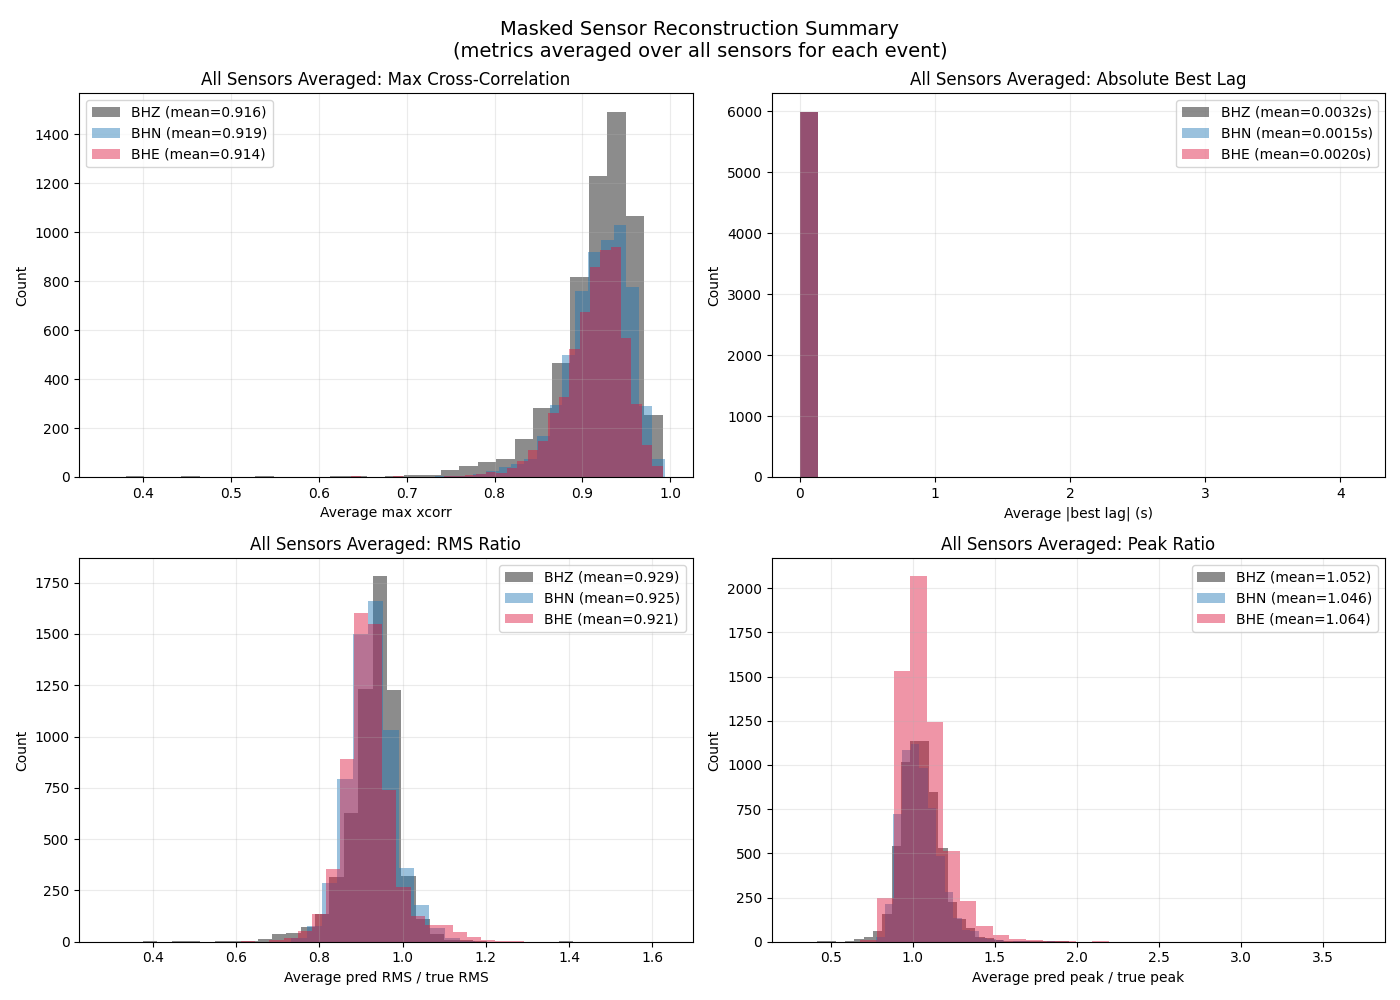

CPU times: user 7min 47s, sys: 51.5 s, total: 8min 38s
Wall time: 8min 20s


In [10]:
%%time
avg_results_df, raw_results_df = evaluate_component_reconstruction_metrics_all_sensors(
    model=vasa,
    X_test=X_test,
    D_norm=D_norm,
    global_center=global_center,
    global_scale=global_scale,
    station_order=station_order,
    meta_test=meta_test,
    batch_size=32,
    output_gain=1.0,
    final_clip=100.0,
    plot_inverse=True,
    save_csv_path="sensor_reconstruction_summary_csv/all_sensors_avg_component_metrics.csv"
)

fig, axes = plot_component_reconstruction_summary_all_sensors(
    avg_results_df,
    save_fig=True,
)


---
Validation attention

In [7]:
%%time
def build_model_inputs_all_single_sensor_masks(
    X_data,
    D_norm,
    global_center,
    global_scale,
    output_gain=1.0,
    final_clip=100.0,
):
    """
    Returns all single-sensor masked versions of X_data.

    If X_data is [N, S, T, 3], output x_model is [N*S, S, T, 6]
    and d_model is [N*S, S, S].

    Also returns masked_sensor_index_per_example of length N*S.
    """
    n_events, sensor_dim, _, _ = X_data.shape

    X_scaled = VASA.global_asinh_scale(
        tf.constant(X_data, dtype=tf.float32),
        global_center=tf.constant(global_center, dtype=tf.float32),
        global_scale=tf.constant(global_scale, dtype=tf.float32),
        output_gain=output_gain,
        final_clip=final_clip
    ).numpy()

    x_models = []
    masked_sensor_ids = []

    for sensor_index in range(sensor_dim):
        mask = np.zeros_like(X_scaled, dtype=np.float32)
        mask[:, sensor_index, :, :] = 1.0

        observed = 1.0 - mask
        X_masked = X_scaled * observed
        x_model_sensor = np.concatenate([X_masked, observed], axis=-1).astype(np.float32)

        x_models.append(x_model_sensor)
        masked_sensor_ids.extend([sensor_index] * n_events)

    x_model = np.concatenate(x_models, axis=0)   # [N*S, S, T, 6]
    d_model = np.broadcast_to(
        D_norm.astype(np.float32),
        (x_model.shape[0],) + D_norm.shape
    ).copy()

    masked_sensor_ids = np.asarray(masked_sensor_ids, dtype=int)

    return x_model, d_model, masked_sensor_ids

x_val_model, d_val_model, masked_ids = build_model_inputs_all_single_sensor_masks(
    X_data=X_test,
    D_norm=D_norm,
    global_center=global_center,
    global_scale=global_scale,
    output_gain=1.0,
    final_clip=100.0,
)

print(x_val_model.shape)   # [N*10, 10, 2400, 6]
print(d_val_model.shape)   # [N*10, 10, 10]

(60000, 10, 2400, 6)
(60000, 10, 10)
CPU times: user 25.1 s, sys: 13.3 s, total: 38.3 s
Wall time: 38.3 s


In [8]:
%%time
attn = VASA.extract_cross_component_attention_summary(
    model=vasa,
    seismic_input=x_val_model,      # [N, S, T, 6]
    distance_input=d_val_model,     # [N, S, S] or [S, S]
    station_order=station_order,
    batch_size=32,
    focus="masked_sensor",
    include_self=False
)

I0000 00:00:1777921690.038604 1470001 cuda_dnn.cc:529] Loaded cuDNN version 90300


CPU times: user 4min 9s, sys: 4.05 s, total: 4min 13s
Wall time: 4min 15s


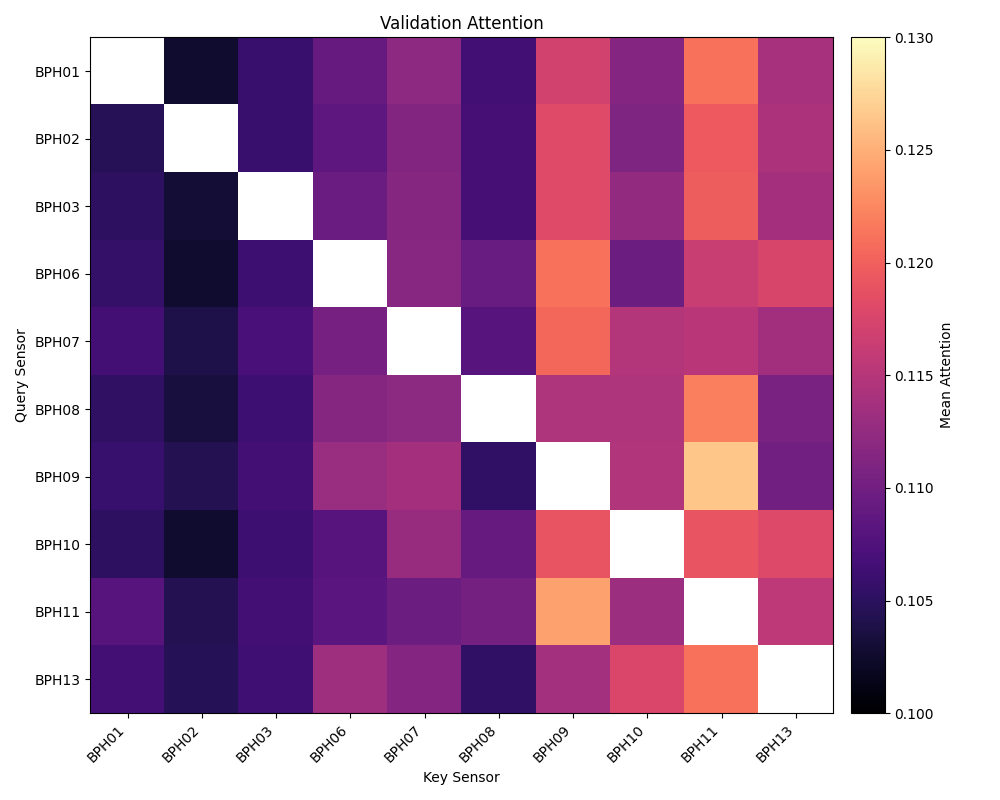

In [22]:
def collapse_attention_heatmap_to_sensor_level(
    attention_results,
    station_order,
    normalize=None,
):
    """
    Collapse a 30x30 token attention heatmap into a sensor-level heatmap.

    Parameters
    ----------
    attention_results : dict
        Output of VASA.extract_cross_component_attention_summary(...)
    station_order : list[str]
        Length-S station list
    normalize : {None, "row", "column"}, optional
        If None, return raw collapsed mean attention.
        If "row", normalize each query-sensor row to sum to 1 (ignoring NaNs).
        If "column", normalize each key-sensor column to sum to 1 (ignoring NaNs).

    Returns
    -------
    sensor_heatmap : np.ndarray, shape [S, S]
    sensor_heatmap_df : pd.DataFrame
    """
    token_heatmap = attention_results["attention_heatmap"]
    sensor_dim = len(station_order)

    if token_heatmap.shape != (3 * sensor_dim, 3 * sensor_dim):
        raise ValueError("attention_heatmap shape does not match station_order.")

    if normalize not in (None, "row", "column"):
        raise ValueError("normalize must be one of: None, 'row', 'column'.")

    sensor_heatmap = np.zeros((sensor_dim, sensor_dim), dtype=np.float64)

    for qi in range(sensor_dim):
        q_rows = [qi, sensor_dim + qi, 2 * sensor_dim + qi]
        for kj in range(sensor_dim):
            k_cols = [kj, sensor_dim + kj, 2 * sensor_dim + kj]
            sensor_heatmap[qi, kj] = np.nanmean(token_heatmap[np.ix_(q_rows, k_cols)])

    sensor_heatmap_df = pd.DataFrame(
        sensor_heatmap,
        index=station_order,
        columns=station_order
    )

    if normalize == "row":
        row_sums = sensor_heatmap_df.sum(axis=1, skipna=True)
        sensor_heatmap_df = sensor_heatmap_df.div(row_sums, axis=0)
    elif normalize == "column":
        col_sums = sensor_heatmap_df.sum(axis=0, skipna=True)
        sensor_heatmap_df = sensor_heatmap_df.div(col_sums, axis=1)

    return sensor_heatmap_df.values, sensor_heatmap_df


def plot_sensor_attention_heatmap(sensor_heatmap_df, figsize=(9, 8), cmap="magma",
                                  vmin=None, vmax=None, title="Sensor-Level Attention Heatmap"):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(sensor_heatmap_df.values, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")

    ax.set_xticks(np.arange(len(sensor_heatmap_df.columns)))
    ax.set_yticks(np.arange(len(sensor_heatmap_df.index)))
    ax.set_xticklabels(sensor_heatmap_df.columns, rotation=45, ha="right")
    ax.set_yticklabels(sensor_heatmap_df.index)

    ax.set_xlabel("Key Sensor")
    ax.set_ylabel("Query Sensor")
    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label("Mean Attention")

    fig.tight_layout()
    return fig, ax


sensor_heatmap_row, sensor_heatmap_df_row = collapse_attention_heatmap_to_sensor_level(
    attn,
    station_order=station_order,
    normalize="row",
)


fig, ax = plot_sensor_attention_heatmap(
    sensor_heatmap_df_row,
    figsize=(10, 8),
    cmap="magma", vmin=0.1, vmax=0.13,
    title="Validation Attention"
)
plt.show()
plt.tight_layout()

In [15]:
%%time
def compute_sensor_reconstruction_summary(
    model,
    X_data,
    D_norm,
    global_center,
    global_scale,
    station_order,
    meta_df=None,
    distance_col="distance_km",
    output_gain=1.0,
    final_clip=100.0,
    batch_size=32,
    max_events=None,
    use_inverse=True,
    eps=1e-10,
):
    """
    Compute per-sensor reconstruction quality summaries for single-sensor masking.

    Parameters
    ----------
    model : tf.keras.Model
        Trained VASA model.
    X_data : ndarray, shape [N, S, T, 3]
        Raw waveform data in model layout.
    D_norm : ndarray, shape [S, S]
        Normalized distance matrix.
    global_center, global_scale : array-like
        Scaling parameters used by the model.
    station_order : list[str]
        Sensor names, length S.
    meta_df : pd.DataFrame or None
        Optional metadata aligned with X_data.
    distance_col : str
        Metadata column for source-receiver distance in km.
    output_gain : float
        Asinh scaling gain.
    final_clip : float
        Final clip used in scaling.
    batch_size : int
        Prediction batch size.
    max_events : int or None
        Optionally limit number of events for speed.
    use_inverse : bool
        If True, compute metrics in inverse-transformed waveform space.
        If False, compute metrics in scaled model space.
    eps : float
        Small constant for safe division.

    Returns
    -------
    results : dict
        Includes event-level, sensor-level, and component-level reconstruction summaries.
    """
    import numpy as np
    import pandas as pd
    import tensorflow as tf

    X_data = np.asarray(X_data, dtype=np.float32)

    if X_data.ndim != 4 or X_data.shape[-1] != 3:
        raise ValueError("X_data must have shape [N, S, T, 3].")

    if max_events is not None:
        X_data = X_data[:max_events]
        if meta_df is not None:
            meta_df = meta_df.iloc[:max_events].reset_index(drop=True)

    n_events, sensor_dim, temporal_dim, _ = X_data.shape

    if len(station_order) != sensor_dim:
        raise ValueError("station_order length must equal sensor_dim.")

    if meta_df is not None and len(meta_df) != n_events:
        raise ValueError("meta_df must be aligned with X_data after max_events slicing.")

    component_names = ["Z", "N", "E"]
    time = np.arange(temporal_dim, dtype=np.float32)

    def _safe_mean(arr):
        arr = np.asarray(arr, dtype=np.float64)
        if np.all(np.isnan(arr)):
            return np.nan
        return float(np.nanmean(arr))

    # --------------------------------------------------
    # Scale once
    # --------------------------------------------------
    X_scaled = VASA.global_asinh_scale(
        tf.constant(X_data, dtype=tf.float32),
        global_center=tf.constant(global_center, dtype=tf.float32),
        global_scale=tf.constant(global_scale, dtype=tf.float32),
        output_gain=output_gain,
        final_clip=final_clip
    ).numpy()

    d_model = np.broadcast_to(
        D_norm.astype(np.float32),
        (n_events,) + D_norm.shape
    ).copy()

    if use_inverse:
        true_eval = VASA.inverse_global_asinh_scale(
            X_scaled,
            global_center,
            global_scale,
            output_gain
        )
    else:
        true_eval = X_scaled

    # --------------------------------------------------
    # Accumulators
    # --------------------------------------------------
    component_mean_xcorr = np.zeros((sensor_dim, 3), dtype=np.float64)
    component_mean_rmse = np.zeros((sensor_dim, 3), dtype=np.float64)
    component_mean_normalized_rmse = np.zeros((sensor_dim, 3), dtype=np.float64)
    component_mean_rms_ratio = np.zeros((sensor_dim, 3), dtype=np.float64)
    component_mean_peak_ratio = np.zeros((sensor_dim, 3), dtype=np.float64)

    component_event_rows = []
    sensor_event_rows = []

    # --------------------------------------------------
    # Loop over masked sensors
    # --------------------------------------------------
    for sensor_index, station in enumerate(station_order):
        mask = np.zeros_like(X_scaled, dtype=np.float32)
        mask[:, sensor_index, :, :] = 1.0

        observed = 1.0 - mask
        X_masked = X_scaled * observed
        x_model = np.concatenate([X_masked, observed], axis=-1).astype(np.float32)

        preds = model.predict(
            {
                "seismic_input": x_model,
                "distance_input": d_model
            },
            batch_size=batch_size,
            verbose=0
        )

        y_pred_scaled = VASA.get_3branch_predictions(preds)

        if use_inverse:
            pred_eval = VASA.inverse_global_asinh_scale(
                y_pred_scaled,
                global_center,
                global_scale,
                output_gain
            )
        else:
            pred_eval = y_pred_scaled

        # Per-component/per-event metrics
        for ci, comp in enumerate(component_names):
            vals_xcorr = []
            vals_rmse = []
            vals_nrmse = []
            vals_rms_ratio = []
            vals_peak_ratio = []

            for ei in range(n_events):
                true_sig = true_eval[ei, sensor_index, :, ci]
                pred_sig = pred_eval[ei, sensor_index, :, ci]

                lags_sec, xcorr_vals = VASA.norm_xcorr(time, true_sig, pred_sig)
                if xcorr_vals is None:
                    max_xcorr = np.nan
                    best_lag_sec = np.nan
                else:
                    best_idx = int(np.argmax(xcorr_vals))
                    max_xcorr = float(np.max(xcorr_vals))
                    best_lag_sec = float(lags_sec[best_idx])

                rmse = float(np.sqrt(np.mean((pred_sig - true_sig) ** 2)))
                true_rms = float(np.sqrt(np.mean(true_sig ** 2)))
                pred_rms = float(np.sqrt(np.mean(pred_sig ** 2)))
                true_peak = float(np.max(np.abs(true_sig)))
                pred_peak = float(np.max(np.abs(pred_sig)))

                normalized_rmse = rmse / (true_rms + eps)
                rms_ratio = pred_rms / (true_rms + eps)
                peak_ratio = pred_peak / (true_peak + eps)

                vals_xcorr.append(max_xcorr)
                vals_rmse.append(rmse)
                vals_nrmse.append(normalized_rmse)
                vals_rms_ratio.append(rms_ratio)
                vals_peak_ratio.append(peak_ratio)

                row = {
                    "event_index": ei,
                    "sensor_index": sensor_index,
                    "station": station,
                    "component": comp,
                    "max_xcorr": max_xcorr,
                    "best_lag_sec": best_lag_sec,
                    "rmse": rmse,
                    "normalized_rmse": normalized_rmse,
                    "rms_ratio": rms_ratio,
                    "peak_ratio": peak_ratio,
                }

                if meta_df is not None:
                    meta = meta_df.iloc[ei]
                    row["EVID"] = meta.get("EVID", meta.get("ev_id", np.nan))
                    row["distance_km"] = meta.get(distance_col, np.nan)
                    row["azimuth_deg"] = meta.get("azimuth_deg", np.nan)
                    row["back_azimuth_deg"] = meta.get("back_azimuth_deg", np.nan)

                component_event_rows.append(row)

            component_mean_xcorr[sensor_index, ci] = _safe_mean(vals_xcorr)
            component_mean_rmse[sensor_index, ci] = _safe_mean(vals_rmse)
            component_mean_normalized_rmse[sensor_index, ci] = _safe_mean(vals_nrmse)
            component_mean_rms_ratio[sensor_index, ci] = _safe_mean(vals_rms_ratio)
            component_mean_peak_ratio[sensor_index, ci] = _safe_mean(vals_peak_ratio)

        # Per-event, averaged across components
        for ei in range(n_events):
            df_tmp = pd.DataFrame([
                r for r in component_event_rows
                if r["event_index"] == ei and r["sensor_index"] == sensor_index
            ])

            sensor_row = {
                "event_index": ei,
                "sensor_index": sensor_index,
                "station": station,
                "mean_max_xcorr": df_tmp["max_xcorr"].mean(),
                "mean_rmse": df_tmp["rmse"].mean(),
                "mean_normalized_rmse": df_tmp["normalized_rmse"].mean(),
                "mean_rms_ratio": df_tmp["rms_ratio"].mean(),
                "mean_peak_ratio": df_tmp["peak_ratio"].mean(),
            }

            if meta_df is not None:
                meta = meta_df.iloc[ei]
                sensor_row["EVID"] = meta.get("EVID", meta.get("ev_id", np.nan))
                sensor_row["distance_km"] = meta.get(distance_col, np.nan)
                sensor_row["azimuth_deg"] = meta.get("azimuth_deg", np.nan)
                sensor_row["back_azimuth_deg"] = meta.get("back_azimuth_deg", np.nan)

            sensor_event_rows.append(sensor_row)

    # --------------------------------------------------
    # Aggregate summaries
    # --------------------------------------------------
    sensor_mean_xcorr = component_mean_xcorr.mean(axis=1)
    sensor_mean_rmse = component_mean_rmse.mean(axis=1)
    sensor_mean_normalized_rmse = component_mean_normalized_rmse.mean(axis=1)
    sensor_mean_rms_ratio = component_mean_rms_ratio.mean(axis=1)
    sensor_mean_peak_ratio = component_mean_peak_ratio.mean(axis=1)

    sensor_summary = pd.DataFrame({
        "sensor_index": np.arange(sensor_dim),
        "station": station_order,
        "mean_max_xcorr": sensor_mean_xcorr,
        "mean_rmse": sensor_mean_rmse,
        "mean_normalized_rmse": sensor_mean_normalized_rmse,
        "mean_rms_ratio": sensor_mean_rms_ratio,
        "mean_peak_ratio": sensor_mean_peak_ratio,
        "mean_max_xcorr_Z": component_mean_xcorr[:, 0],
        "mean_max_xcorr_N": component_mean_xcorr[:, 1],
        "mean_max_xcorr_E": component_mean_xcorr[:, 2],
        "mean_rmse_Z": component_mean_rmse[:, 0],
        "mean_rmse_N": component_mean_rmse[:, 1],
        "mean_rmse_E": component_mean_rmse[:, 2],
        "mean_rms_ratio_Z": component_mean_rms_ratio[:, 0],
        "mean_rms_ratio_N": component_mean_rms_ratio[:, 1],
        "mean_rms_ratio_E": component_mean_rms_ratio[:, 2],
        "mean_peak_ratio_Z": component_mean_peak_ratio[:, 0],
        "mean_peak_ratio_N": component_mean_peak_ratio[:, 1],
        "mean_peak_ratio_E": component_mean_peak_ratio[:, 2],
    }).sort_values("mean_max_xcorr", ascending=True, ignore_index=True)

    component_summary = pd.DataFrame(component_event_rows)
    component_summary = (
        component_summary
        .groupby(["sensor_index", "station", "component"], as_index=False)[
            ["max_xcorr", "rmse", "normalized_rmse", "rms_ratio", "peak_ratio"]
        ]
        .mean()
        .sort_values("max_xcorr", ascending=True, ignore_index=True)
    )

    sensor_event_metrics = pd.DataFrame(sensor_event_rows)
    component_event_metrics = pd.DataFrame(component_event_rows)

    # Row-wise repeated matrices for visual alignment with attention heatmaps
    xcorr_matrix = np.tile(sensor_mean_xcorr[:, None], (1, sensor_dim))
    rmse_matrix = np.tile(sensor_mean_rmse[:, None], (1, sensor_dim))
    rms_ratio_matrix = np.tile(sensor_mean_rms_ratio[:, None], (1, sensor_dim))
    peak_ratio_matrix = np.tile(sensor_mean_peak_ratio[:, None], (1, sensor_dim))

    xcorr_matrix_df = pd.DataFrame(xcorr_matrix, index=station_order, columns=station_order)
    rmse_matrix_df = pd.DataFrame(rmse_matrix, index=station_order, columns=station_order)
    rms_ratio_matrix_df = pd.DataFrame(rms_ratio_matrix, index=station_order, columns=station_order)
    peak_ratio_matrix_df = pd.DataFrame(peak_ratio_matrix, index=station_order, columns=station_order)

    results = {
        "sensor_mean_xcorr": sensor_mean_xcorr,
        "sensor_mean_rmse": sensor_mean_rmse,
        "sensor_mean_normalized_rmse": sensor_mean_normalized_rmse,
        "sensor_mean_rms_ratio": sensor_mean_rms_ratio,
        "sensor_mean_peak_ratio": sensor_mean_peak_ratio,
        "component_mean_xcorr": component_mean_xcorr,
        "component_mean_rmse": component_mean_rmse,
        "component_mean_normalized_rmse": component_mean_normalized_rmse,
        "component_mean_rms_ratio": component_mean_rms_ratio,
        "component_mean_peak_ratio": component_mean_peak_ratio,
        "sensor_summary": sensor_summary,
        "component_summary": component_summary,
        "sensor_event_metrics": sensor_event_metrics,
        "component_event_metrics": component_event_metrics,
        "matrix": xcorr_matrix,
        "matrix_df": xcorr_matrix_df,
        "rmse_matrix_df": rmse_matrix_df,
        "rms_ratio_matrix_df": rms_ratio_matrix_df,
        "peak_ratio_matrix_df": peak_ratio_matrix_df,
    }

    return results

CPU times: user 8 μs, sys: 0 ns, total: 8 μs
Wall time: 15.5 μs


In [16]:
%%time
summary = compute_sensor_reconstruction_summary(
    model=vasa,
    X_data=X_test,
    D_norm=D_norm,
    global_center=global_center,
    global_scale=global_scale,
    station_order=station_order,
    meta_df=meta_test,
    batch_size=32,
    output_gain=1.0,
    final_clip=100.0,
    use_inverse=True,
)

print(summary["sensor_summary"][[
    "station", "mean_max_xcorr", "mean_rmse", "mean_normalized_rmse",
    "mean_rms_ratio", "mean_peak_ratio"
]])

  station  mean_max_xcorr     mean_rmse  mean_normalized_rmse  mean_rms_ratio  \
0   BPH11        0.538250  3.394281e-07              1.013466        0.824652   
1   BPH10        0.613852  3.072489e-07              0.897478        0.796478   
2   BPH09        0.635185  1.221825e-06              1.072014        1.112767   
3   BPH13        0.658506  2.308234e-07              0.903567        0.936973   
4   BPH08        0.666113  9.341424e-07              1.292738        1.479105   
5   BPH07        0.705213  3.482480e-07              0.913054        1.074692   
6   BPH06        0.735068  2.658757e-07              0.807729        0.998767   
7   BPH01        0.835196  1.959603e-07              0.591027        0.979481   
8   BPH03        0.889056  1.498182e-07              0.475994        0.959797   
9   BPH02        0.893833  1.793698e-07              0.455866        0.956672   

   mean_peak_ratio  
0         1.936577  
1         1.668599  
2         2.515809  
3         1.868438  
4  

In [17]:
# Saving
outdir = Path("sensor_reconstruction_summary_csv")
outdir.mkdir(exist_ok=True)

summary["sensor_summary"].to_csv(outdir / "sensor_summary.csv", index=False)
summary["component_summary"].to_csv(outdir / "component_summary.csv", index=False)
summary["sensor_event_metrics"].to_csv(outdir / "sensor_event_metrics.csv", index=False)
summary["component_event_metrics"].to_csv(outdir / "component_event_metrics.csv", index=False)

summary["matrix_df"].to_csv(outdir / "xcorr_matrix.csv")
summary["rmse_matrix_df"].to_csv(outdir / "rmse_matrix.csv")
summary["rms_ratio_matrix_df"].to_csv(outdir / "rms_ratio_matrix.csv")
summary["peak_ratio_matrix_df"].to_csv(outdir / "peak_ratio_matrix.csv")

if "mag_by_sensor_summary" in summary:
    summary["mag_by_sensor_summary"].to_csv(outdir / "mag_by_sensor_summary.csv", index=False)

if "mag_by_distance_summary" in summary:
    summary["mag_by_distance_summary"].to_csv(outdir / "mag_by_distance_summary.csv", index=False)

if "mag_by_sensor_distance_summary" in summary:
    summary["mag_by_sensor_distance_summary"].to_csv(outdir / "mag_by_sensor_distance_summary.csv", index=False)

if "overall_mag_summary" in summary:
    pd.DataFrame([summary["overall_mag_summary"]]).to_csv(outdir / "overall_mag_summary.csv", index=False)

print(f"Saved CSV files to: {outdir}")

Saved CSV files to: sensor_reconstruction_summary_150_tprime_10Hz_csv


---
Plotting xcorr, rms ratio, peak ratio

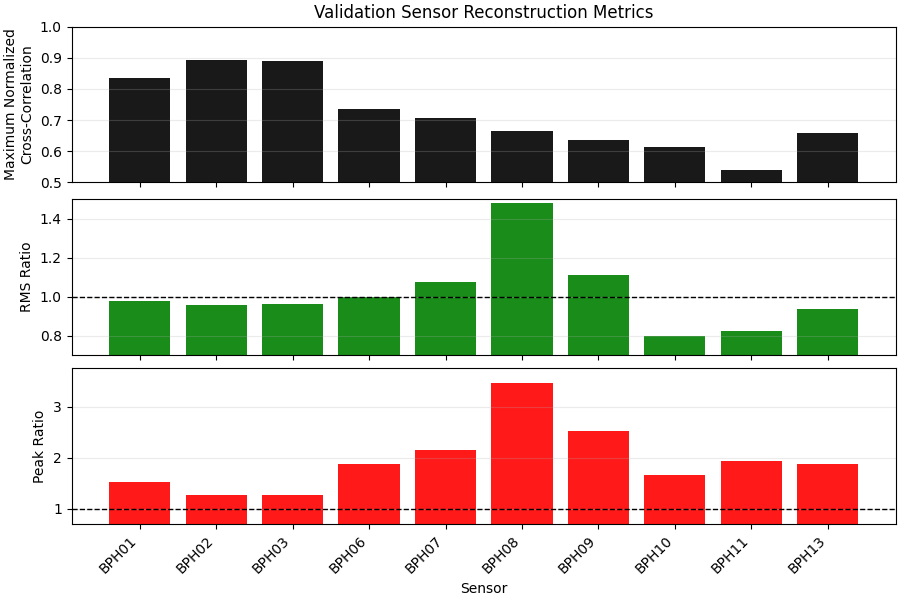

CPU times: user 588 ms, sys: 12 ms, total: 600 ms
Wall time: 599 ms


In [29]:
%%time
def plot_sensor_reconstruction_metrics(
    sensor_summary,
    station_order,
    figsize=(12, 8),
    title="Sensor Reconstruction Metrics",
    xcorr_color="black",
    rms_color="green",
    peak_color="red",
):
    """
    Plot per-sensor reconstruction metrics in fixed station order.

    Parameters
    ----------
    sensor_summary : pd.DataFrame
        Typically summary["sensor_summary"] from
        compute_sensor_reconstruction_xcorr_summary(...)

    station_order : list[str]
        Desired plotting order, e.g.
        ["BPH01", "BPH02", ..., "BPH13"]

    Returns
    -------
    fig, axes
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    df = sensor_summary.copy()
    df["station"] = pd.Categorical(df["station"], categories=station_order, ordered=True)
    df = df.sort_values("station").reset_index(drop=True)

    stations = df["station"].astype(str).tolist()
    x = np.arange(len(stations))

    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True, constrained_layout=True)

    # 1. Mean max xcorr
    axes[0].bar(x, df["mean_max_xcorr"], color=xcorr_color, alpha=0.9)
    axes[0].set_ylabel("Maximum Normalized\nCross-Correlation")
    axes[0].set_title(title)
    axes[0].grid(True, axis="y", alpha=0.25)
    axes[0].set_ylim(0.5,1)

    # 2. Mean RMS ratio
    axes[1].bar(x, df["mean_rms_ratio"], color=rms_color, alpha=0.9)
    axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1)
    axes[1].set_ylabel("RMS Ratio")
    axes[1].grid(True, axis="y", alpha=0.25)
    axes[1].set_ylim(0.7,1.5)

    # 3. Mean peak ratio
    axes[2].bar(x, df["mean_peak_ratio"], color=peak_color, alpha=0.9)
    axes[2].axhline(1.0, color="black", linestyle="--", linewidth=1)
    axes[2].set_ylabel("Peak Ratio")
    axes[2].set_xlabel("Sensor")
    axes[2].grid(True, axis="y", alpha=0.25)
    axes[2].set_ylim(0.7,3.75)

    axes[2].set_xticks(x)
    axes[2].set_xticklabels(stations, rotation=45, ha="right")

    return fig, axes

fig, axes = plot_sensor_reconstruction_metrics(
    sensor_summary=summary["sensor_summary"],
    station_order=station_order,
    figsize=(9, 6),
    title="Validation Sensor Reconstruction Metrics"
)
plt.show()
plt.tight_layout
fig.savefig("Figures/Validation_Reconstruction_Quality_150tprime_10Hz.png", dpi=300)

---
Comparing BPH09 reconstruction with BPH11 and without BPH11 (zeroed out) - also with and without BPH02

In [17]:
%%time
def compare_target_with_without_context_sensor(
    model,
    X_data,
    D_norm,
    global_center,
    global_scale,
    station_order,
    target_station="BPH09",
    drop_station="BPH11",
    output_gain=1.0,
    final_clip=100.0,
    batch_size=32,
    max_events=None,
):
    """
    Compare reconstruction of target_station with normal context vs one context
    sensor removed.

    Assumes:
      X_data shape = [N, S, T, 3]
      channel order = [Z, N, E]
    """
    X_data = np.asarray(X_data, dtype=np.float32)
    if X_data.ndim != 4 or X_data.shape[-1] != 3:
        raise ValueError("X_data must have shape [N, S, T, 3].")

    if max_events is not None:
        X_data = X_data[:max_events]

    n_events, sensor_dim, temporal_dim, _ = X_data.shape
    time = np.arange(temporal_dim, dtype=np.float32)

    target_idx = station_order.index(target_station)
    drop_idx = station_order.index(drop_station)
    comp_names = ["Z", "N", "E"]

    # Scale once
    X_scaled = VASA.global_asinh_scale(
        tf.constant(X_data, dtype=tf.float32),
        global_center=tf.constant(global_center, dtype=tf.float32),
        global_scale=tf.constant(global_scale, dtype=tf.float32),
        output_gain=output_gain,
        final_clip=final_clip
    ).numpy()

    true_full = VASA.inverse_global_asinh_scale(
        X_scaled, global_center, global_scale, output_gain
    )

    d_model = np.broadcast_to(
        D_norm.astype(np.float32),
        (n_events,) + D_norm.shape
    ).copy()

    def run_case(drop_context=False):
        observed = np.ones_like(X_scaled, dtype=np.float32)

        # Always mask target sensor
        observed[:, target_idx, :, :] = 0.0

        # Optionally remove another context sensor
        if drop_context:
            observed[:, drop_idx, :, :] = 0.0

        x_masked = X_scaled * observed
        x_model = np.concatenate([x_masked, observed], axis=-1).astype(np.float32)

        preds = model.predict(
            {
                "seismic_input": x_model,
                "distance_input": d_model
            },
            batch_size=batch_size,
            verbose=0
        )

        pred_scaled = VASA.get_3branch_predictions(preds)
        pred_full = VASA.inverse_global_asinh_scale(
            pred_scaled, global_center, global_scale, output_gain
        )

        rows = []
        for ei in range(n_events):
            for ci, comp in enumerate(comp_names):
                true_sig = true_full[ei, target_idx, :, ci]
                pred_sig = pred_full[ei, target_idx, :, ci]

                lags_sec, xcorr_vals = VASA.norm_xcorr(time, true_sig, pred_sig)
                best_idx = int(np.argmax(xcorr_vals))
                max_xcorr = float(xcorr_vals[best_idx])
                best_lag_sec = float(lags_sec[best_idx])

                rmse = float(np.sqrt(np.mean((pred_sig - true_sig) ** 2)))
                true_rms = float(np.sqrt(np.mean(true_sig ** 2)))
                pred_rms = float(np.sqrt(np.mean(pred_sig ** 2)))
                rms_ratio = np.nan if true_rms == 0 else pred_rms / true_rms

                true_peak = float(np.max(np.abs(true_sig)))
                pred_peak = float(np.max(np.abs(pred_sig)))
                peak_ratio = np.nan if true_peak == 0 else pred_peak / true_peak

                rows.append({
                    "event_index": ei,
                    "component": comp,
                    "max_xcorr": max_xcorr,
                    "best_lag_sec": best_lag_sec,
                    "rmse": rmse,
                    "rms_ratio": rms_ratio,
                    "peak_ratio": peak_ratio,
                })

        return pd.DataFrame(rows)

    baseline_df = run_case(drop_context=False)
    drop_df = run_case(drop_context=True)

    baseline_df["case"] = "baseline"
    drop_df["case"] = f"drop_{drop_station}"

    results_df = pd.concat([baseline_df, drop_df], ignore_index=True)

    summary_by_component = (
        results_df
        .groupby(["case", "component"])[["max_xcorr", "best_lag_sec", "rmse", "rms_ratio", "peak_ratio"]]
        .mean()
        .reset_index()
    )

    summary_overall = (
        results_df
        .groupby("case")[["max_xcorr", "best_lag_sec", "rmse", "rms_ratio", "peak_ratio"]]
        .mean()
        .reset_index()
    )

    paired = baseline_df.merge(
        drop_df,
        on=["event_index", "component"],
        suffixes=("_baseline", "_drop")
    )

    paired["delta_max_xcorr"] = paired["max_xcorr_drop"] - paired["max_xcorr_baseline"]
    paired["delta_rmse"] = paired["rmse_drop"] - paired["rmse_baseline"]
    paired["delta_best_lag_sec"] = paired["best_lag_sec_drop"] - paired["best_lag_sec_baseline"]
    paired["delta_rms_ratio"] = paired["rms_ratio_drop"] - paired["rms_ratio_baseline"]
    paired["delta_peak_ratio"] = paired["peak_ratio_drop"] - paired["peak_ratio_baseline"]

    delta_by_component = (
        paired
        .groupby("component")[["delta_max_xcorr", "delta_rmse", "delta_best_lag_sec", "delta_rms_ratio", "delta_peak_ratio"]]
        .mean()
        .reset_index()
    )

    delta_overall = paired[["delta_max_xcorr", "delta_rmse", "delta_best_lag_sec", "delta_rms_ratio", "delta_peak_ratio"]].mean()

    hurt_rate = (
        paired.groupby("component")
        .apply(lambda g: pd.Series({
            "frac_xcorr_worse_when_drop_context": np.mean(g["delta_max_xcorr"] < 0),
            "frac_rmse_worse_when_drop_context": np.mean(g["delta_rmse"] > 0),
        }))
        .reset_index()
    )

    return {
        "target_station": target_station,
        "drop_station": drop_station,
        "event_level_results": results_df,
        "summary_by_component": summary_by_component,
        "summary_overall": summary_overall,
        "paired_event_component_results": paired,
        "delta_by_component": delta_by_component,
        "delta_overall": delta_overall,
        "hurt_rate": hurt_rate,
    }

CPU times: user 12 μs, sys: 0 ns, total: 12 μs
Wall time: 22.4 μs


In [18]:
%%time
cmp = compare_target_with_without_context_sensor(
    model=vasa,
    X_data=X_test,
    D_norm=D_norm,
    global_center=global_center,
    global_scale=global_scale,
    station_order=station_order,
    target_station="BPH09",
    drop_station="BPH11",
    output_gain=1.0,
    final_clip=100.0,
    batch_size=32,
    max_events=None,
)

print("\nOverall means:")
print(cmp["summary_overall"])

print("\nBy component:")
print(cmp["summary_by_component"])

print("\nMean change when BPH11 is removed (drop - baseline):")
print(cmp["delta_by_component"])

print("\nOverall delta:")
print(cmp["delta_overall"])

print("\nHow often removing BPH11 hurts:")
print(cmp["hurt_rate"])



Overall means:
         case  max_xcorr  best_lag_sec          rmse  rms_ratio  peak_ratio
0    baseline   0.868841       -0.0435  8.173014e-08   0.888881    1.133199
1  drop_BPH11   0.763007       -0.1170  1.001443e-07   0.636396    0.726610

By component:
         case component  max_xcorr  best_lag_sec          rmse  rms_ratio  \
0    baseline         E   0.865158     -0.026000  8.435606e-08   0.886790   
1    baseline         N   0.865231     -0.023833  8.760313e-08   0.873908   
2    baseline         Z   0.876133     -0.080667  7.323122e-08   0.905945   
3  drop_BPH11         E   0.755199     -0.074167  1.018742e-07   0.723206   
4  drop_BPH11         N   0.740289     -0.228000  1.138337e-07   0.463365   
5  drop_BPH11         Z   0.793535     -0.048833  8.472508e-08   0.722619   

   peak_ratio  
0    1.146730  
1    1.115580  
2    1.137287  
3    0.843409  
4    0.594928  
5    0.741493  

Mean change when BPH11 is removed (drop - baseline):
  component  delta_max_xcorr    del

In [19]:
%%time
cmp_bph02 = compare_target_with_without_context_sensor(
    model=vasa,
    X_data=X_test,
    D_norm=D_norm,
    global_center=global_center,
    global_scale=global_scale,
    station_order=station_order,
    target_station="BPH09",
    drop_station="BPH02",
    output_gain=1.0,
    final_clip=100.0,
    batch_size=32,
    max_events=None,
)

print("\nOverall means:")
print(cmp_bph02["summary_overall"])

print("\nBy component:")
print(cmp_bph02["summary_by_component"])

print("\nMean change when BPH02 is removed (drop - baseline):")
print(cmp_bph02["delta_by_component"])

print("\nOverall delta:")
print(cmp_bph02["delta_overall"])

print("\nHow often removing BPH02 hurts:")
print(cmp_bph02["hurt_rate"])



Overall means:
         case  max_xcorr  best_lag_sec          rmse  rms_ratio  peak_ratio
0    baseline   0.868841     -0.043500  8.173014e-08   0.888881    1.133199
1  drop_BPH02   0.778405      0.266778  1.018064e-07   0.590834    0.734295

By component:
         case component  max_xcorr  best_lag_sec          rmse  rms_ratio  \
0    baseline         E   0.865158     -0.026000  8.435606e-08   0.886790   
1    baseline         N   0.865231     -0.023833  8.760313e-08   0.873908   
2    baseline         Z   0.876133     -0.080667  7.323122e-08   0.905945   
3  drop_BPH02         E   0.779962      0.171167  1.023172e-07   0.503194   
4  drop_BPH02         N   0.756930      0.240667  1.114313e-07   0.710400   
5  drop_BPH02         Z   0.798322      0.388500  9.167060e-08   0.558909   

   peak_ratio  
0    1.146730  
1    1.115580  
2    1.137287  
3    0.644774  
4    0.925830  
5    0.632280  

Mean change when BPH02 is removed (drop - baseline):
  component  delta_max_xcorr    del

---
Comparing BPH02 and BPH11 results for reconstructing BPH09

In [20]:
print("Drop BPH11 overall delta:")
print(cmp["delta_overall"])          # your earlier BPH11 result

print("\nDrop BPH02 overall delta:")
print(cmp_bph02["delta_overall"])


Drop BPH11 overall delta:
delta_max_xcorr      -1.058331e-01
delta_rmse            1.841421e-08
delta_best_lag_sec   -7.350000e-02
delta_rms_ratio      -2.524848e-01
delta_peak_ratio     -4.065888e-01
dtype: float64

Drop BPH02 overall delta:
delta_max_xcorr      -9.043591e-02
delta_rmse            2.007625e-08
delta_best_lag_sec    3.102778e-01
delta_rms_ratio      -2.980469e-01
delta_peak_ratio     -3.989043e-01
dtype: float64


---
Plotting train and test set event locations 

In [22]:
%%time
def plot_train_test_event_rose(
    meta_train,
    meta_test,
    azimuth_col="azimuth_deg",
    distance_col="distance_km",
    train_label="Train",
    test_label="Test",
    train_color="0.55",
    test_color="crimson",
    train_alpha=0.55,
    test_alpha=0.75,
    train_size=14,
    test_size=18,
    figsize=(8, 8),
    save_fig=False,
    save_path=None,
    dpi=300,
):
    """
    Plot train and test events on a rose-style azimuth-distance scatter plot.
    """

    def _prep(df, label):
        if azimuth_col not in df.columns:
            raise KeyError(f"{azimuth_col!r} not found in {label} DataFrame.")
        if distance_col not in df.columns:
            raise KeyError(f"{distance_col!r} not found in {label} DataFrame.")

        out = df.copy()
        out[azimuth_col] = pd.to_numeric(out[azimuth_col], errors="coerce")
        out[distance_col] = pd.to_numeric(out[distance_col], errors="coerce")
        out = out.dropna(subset=[azimuth_col, distance_col]).copy()

        out["azimuth_deg_360"] = np.mod(out[azimuth_col], 360.0)
        out["theta"] = np.deg2rad(out["azimuth_deg_360"])
        return out

    train_df = _prep(meta_train, "meta_train")
    test_df = _prep(meta_test, "meta_test")

    fig, ax = plt.subplots(
        figsize=figsize,
        subplot_kw={"projection": "polar"},
        clear=True
    )

    ax.scatter(
        train_df["theta"],
        train_df[distance_col],
        s=train_size,
        c=train_color,
        alpha=train_alpha,
        linewidths=0,
        label=f"{train_label} (N={len(train_df)})"
    )

    ax.scatter(
        test_df["theta"],
        test_df[distance_col],
        s=test_size,
        c=test_color,
        alpha=test_alpha,
        linewidths=0,
        label=f"{test_label} (N={len(test_df)})"
    )

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ticks = np.arange(0, 360, 45)
    labels = ["" if t == 0 else f"{t}°" for t in ticks]
    ax.set_thetagrids(ticks, labels)

    # Put radial tick labels at the top
    ax.set_rlabel_position(0)

    # Remove default ylabel/title behavior and place custom label at top
    rmax = ax.get_ylim()[1]
    ax.text(
        np.deg2rad(0),
        rmax * 1.08,
        "Distance [km]",
        ha="center",
        va="bottom",
        fontsize=12
    )

    ax.grid(alpha=0.25)
    ax.legend(loc="upper right", bbox_to_anchor=(1.22, 1.10))

    fig.tight_layout()

    if save_fig:
        if save_path is None:
            save_path = "train_test_event_rose_plot.png"
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved figure: {save_path}")

    plt.show()

    return fig, ax, train_df, test_df





CPU times: user 13 μs, sys: 1e+03 ns, total: 14 μs
Wall time: 21.5 μs


Saved figure: Figures/Train_Test_Event_Rose.png


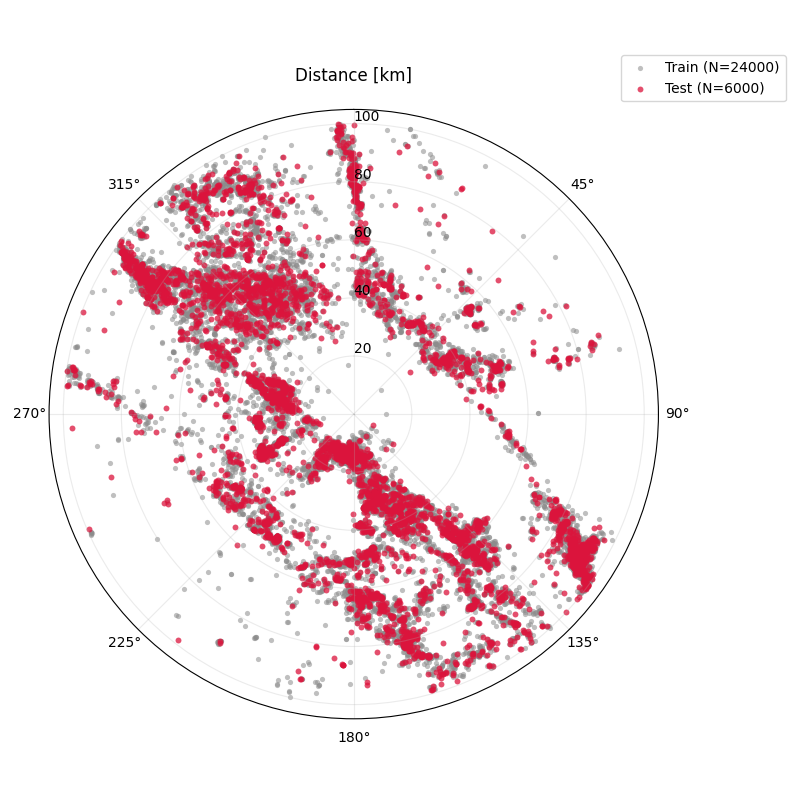

In [23]:
fig, ax, train_plot_df, test_plot_df = plot_train_test_event_rose(
    meta_train,
    meta_test,
    azimuth_col="azimuth_deg",
    distance_col="distance_km",
    save_fig=True,
)


